# EPLB Benchmark Analysis

Compare EPLB configurations across collected benchmark runs.

**Prerequisites:** Collect results with `just eplb-collect <run-name>` before running this notebook.
Each run lives in `benchmarks/eplb/<run-name>/` and contains `config.env`, `prometheus.json`, and `expert-load/` dumps.

See `benchmarks/eplb/README.md` for the full benchmark plan and execution steps.

In [1]:
%load_ext autoreload
%autoreload 2

from eplb_analysis import (
    load_run,
    load_all_runs,
    list_runs,
    metrics_comparison_table,
    stage_metrics_table,
    balancedness_comparison_table,
    plot_latency_comparison,
    plot_throughput_comparison,
    plot_throughput_timeseries,
    plot_kv_cache_usage,
    plot_balancedness_comparison,
    plot_latency_timeseries,
    plot_phase_time_comparison,
    plot_phase_time_timeseries,
    plot_pareto_frontier,
    plot_expert_load_all,
    plot_expert_load_heatmap,
    plot_rank_balance,
    plot_expert_popularity,
    plot_balancedness_over_time,
    plot_rank_balance_at_steps
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 30)

## 1. Load Runs

List available runs and load a subset for comparison. Adjust `run_names` to pick the runs you want to analyze.

In [13]:
print("Available runs:")
for name in list_runs():
    print(f"  {name}")

Available runs:
  pd-async-eplb
  pd-async-eplb-both
  pd-async-eplb-both-gloo
  pd-baseline
  pd-no-eplb


In [14]:
# Edit this list to select which runs to compare
run_names = list_runs()  # or e.g. ["pd-no-eplb", "pd-sync-eplb", "pd-async-eplb"]
run_names = ["pd-async-eplb-both", "pd-baseline", "pd-async-eplb-both-gloo"]
runs = {name: load_run(name) for name in run_names}
print(f"Loaded {len(runs)} runs:")
for name, run in runs.items():
    expert_info = ""
    if run.expert_loads:
        n_snaps = sum(e.num_snapshots for e in run.expert_loads.values())
        expert_info = f", {n_snaps} expert snapshots"
    prom_info = "prometheus OK" if run.prometheus else "no prometheus"
    print(f"  {name}: {run.config} | {prom_info}{expert_info}")

Loaded 3 runs:
  pd-async-eplb-both: RunConfig('pd-async-eplb-both', mode=pd, eplb=async, dataset=sharegpt, redundant=32, interval=3000, lws=4, decode=1x4, prefill=2x1) | prometheus OK, 110 expert snapshots
  pd-baseline: RunConfig('pd-baseline', mode=pd, eplb=off, dataset=sharegpt, redundant=32, interval=3000, lws=4, decode=1x4, prefill=2x1) | prometheus OK
  pd-async-eplb-both-gloo: RunConfig('pd-async-eplb-both-gloo', mode=pd, eplb=async, dataset=sharegpt, redundant=32, interval=3000, lws=4, decode=1x4, prefill=2x1) | prometheus OK, 105 expert snapshots


## 2. Metrics Overview

Summary table of Prometheus metrics across runs. Latencies in milliseconds.

In [4]:
df_metrics = metrics_comparison_table(runs)
df_metrics

,mode,eplb,dataset,redundant,interval,lws_size,decode_pods,prefill_pods,prom_duration_m,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,itl_p50_ms,itl_p95_ms,itl_p99_ms,...,queue_p50_ms,queue_p95_ms,queue_p99_ms,prefill_time_p50_ms,prefill_time_p95_ms,prefill_time_p99_ms,decode_time_p50_ms,decode_time_p95_ms,decode_time_p99_ms,gen_tokens_per_sec,prompt_tokens_per_sec,requests_running,requests_waiting,kv_cache_usage,nixl_xfer_p99_ms
run,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
pd-async-eplb-both,pd,async,sharegpt,32,3000,4,4,2,213.767,881.891,5462.529,7838.581,186.008,285.525,298.780,...,368.042,5566.386,9517.081,366.398,1277.354,1490.144,297.521,455783.873,475156.775,73214.686,43570.776,65.000,0.000,0.003,295.651
pd-baseline,pd,off,sharegpt,32,3000,4,4,2,785.050,613.174,105755.927,149151.185,87.686,99.280,133.576,...,160.004,764.747,3937.054,203.070,1157.569,1464.546,292.489,222293.100,236458.620,134714.790,101610.115,11236.000,22.000,0.258,165.841


## 3. Latency Comparison

### 3a. TTFT and ITL per concurrency stage

One group of bars per concurrency stage, one bar per run. Shows at which load level
each configuration starts to degrade.

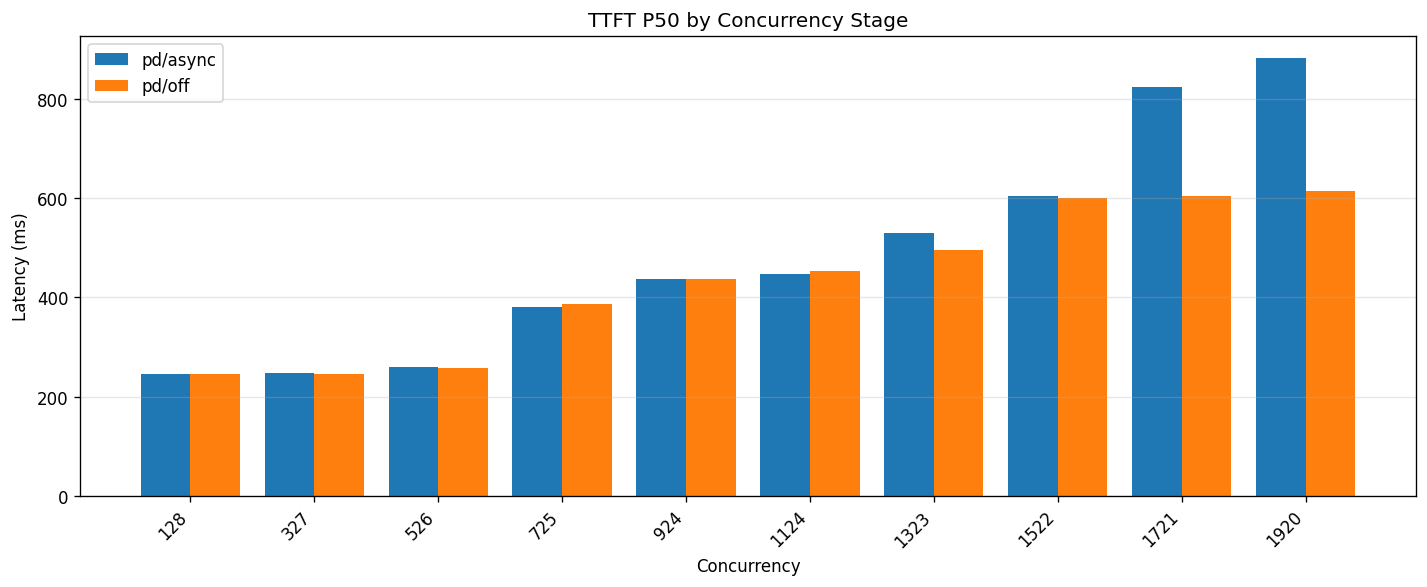

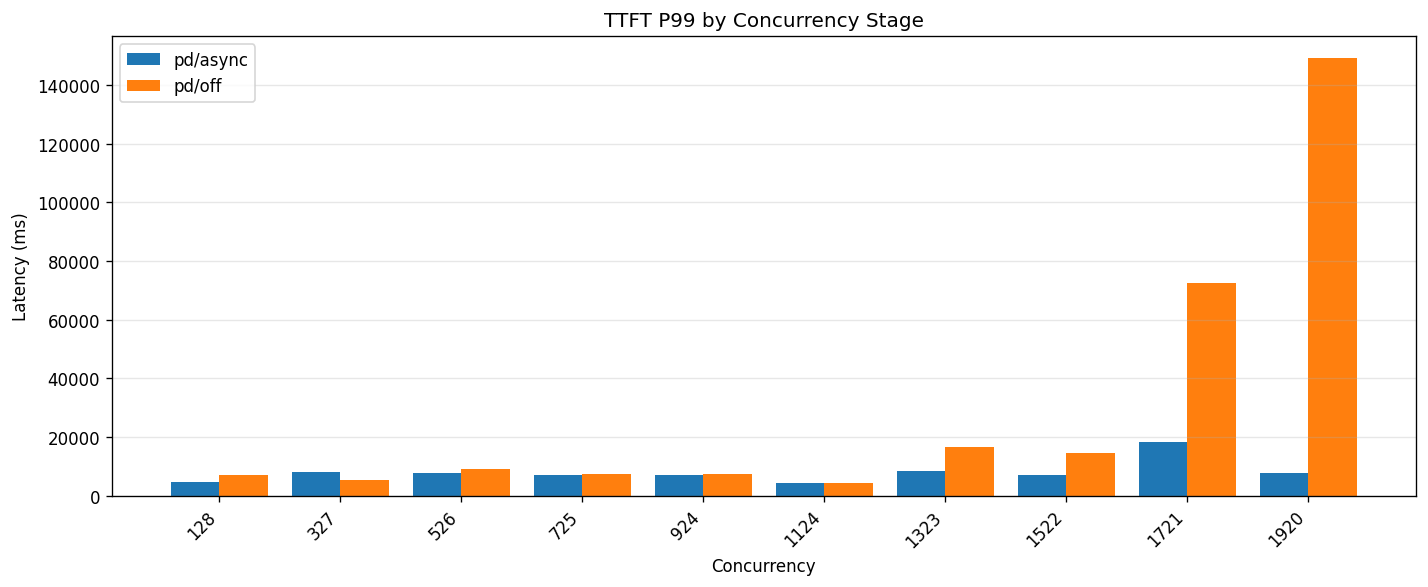

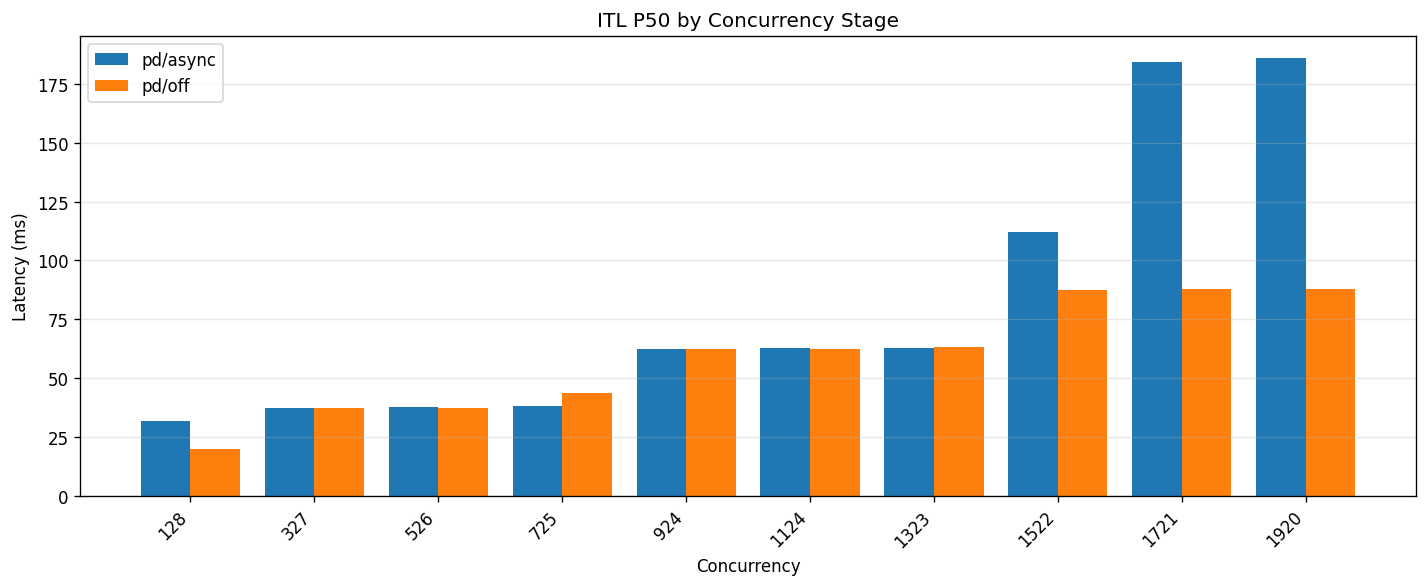

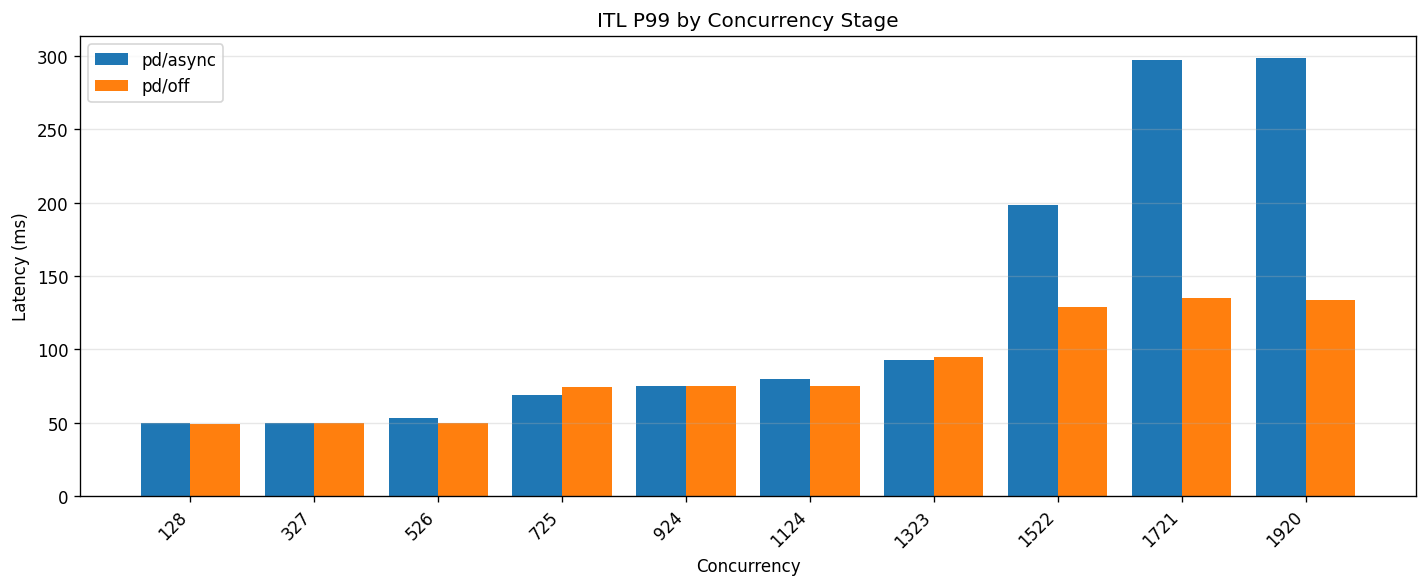

In [5]:
plot_latency_comparison(runs, metric="ttft_p50", title="TTFT P50 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="ttft_p99", title="TTFT P99 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="itl_p50", title="ITL P50 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="itl_p99", title="ITL P99 by Concurrency Stage")
plt.show()

### 3b. Latency time series

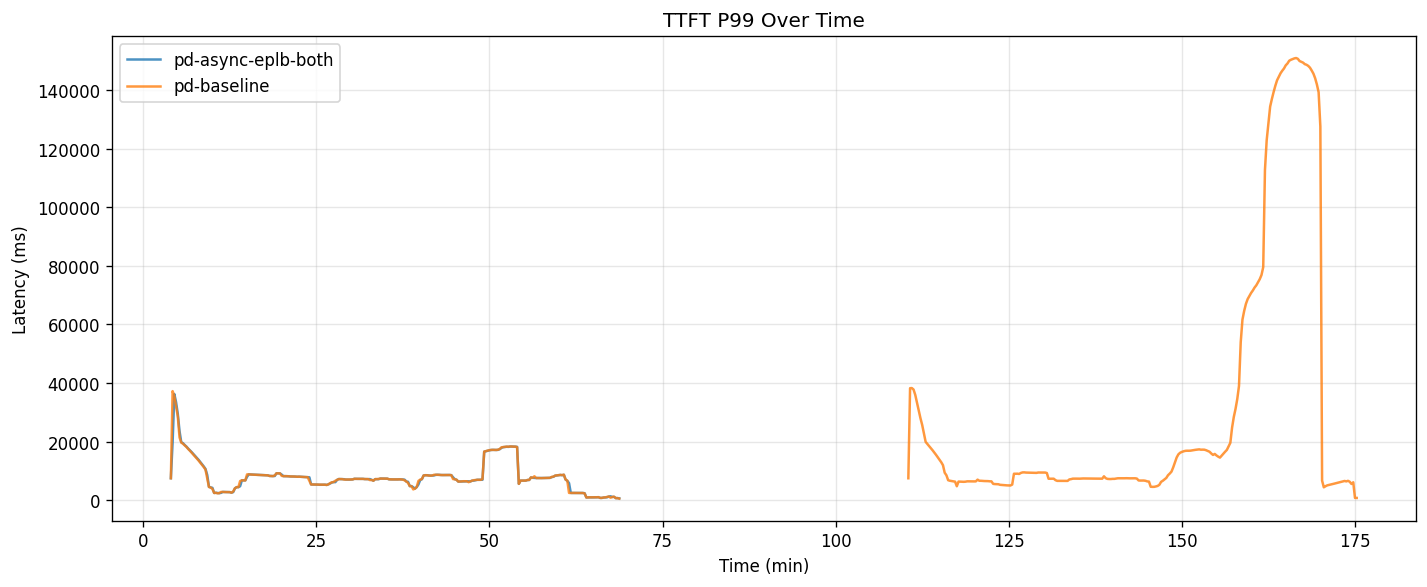

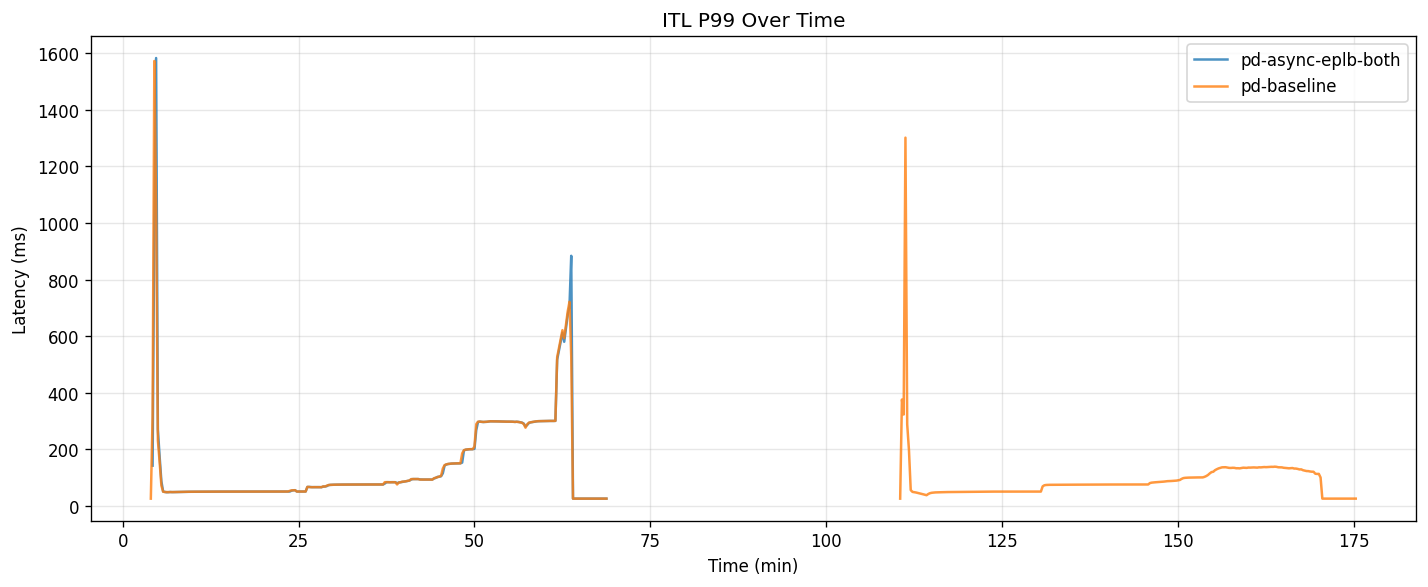

In [6]:
plot_latency_timeseries(runs, "ttft_p99_range", "TTFT P99 Over Time")
plt.show()
plot_latency_timeseries(runs, "itl_p99_range", "ITL P99 Over Time")
plt.show()

### 3c. Phase time breakdown

Where is latency spent? Prefill compute, decode compute, or queue. EPLB primarily affects decode time.

In [ ]:
plot_phase_time_comparison(runs, percentile="p99")
plt.show()
plot_phase_time_comparison(runs, percentile="p50")
plt.show()
plot_phase_time_timeseries(runs)
plt.show()

## 4. Throughput Comparison

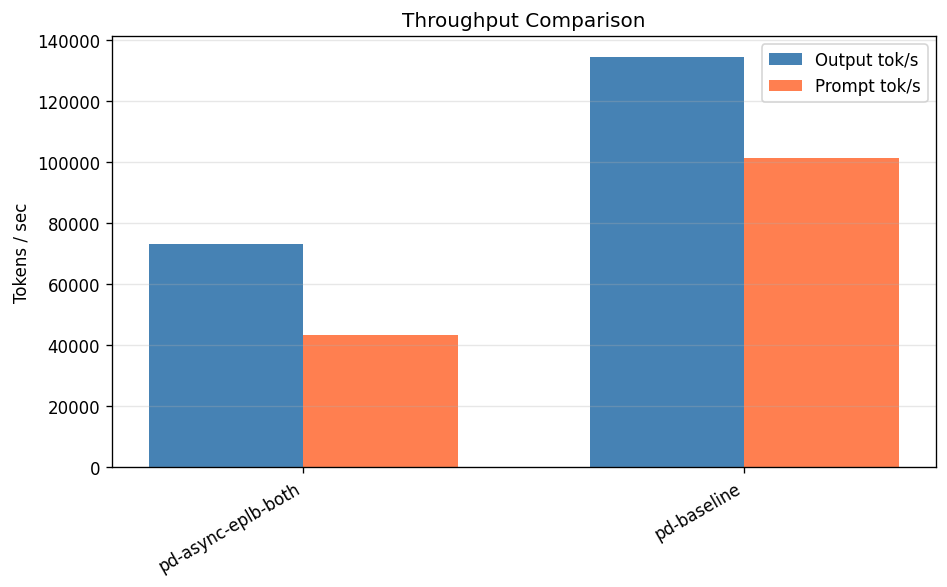

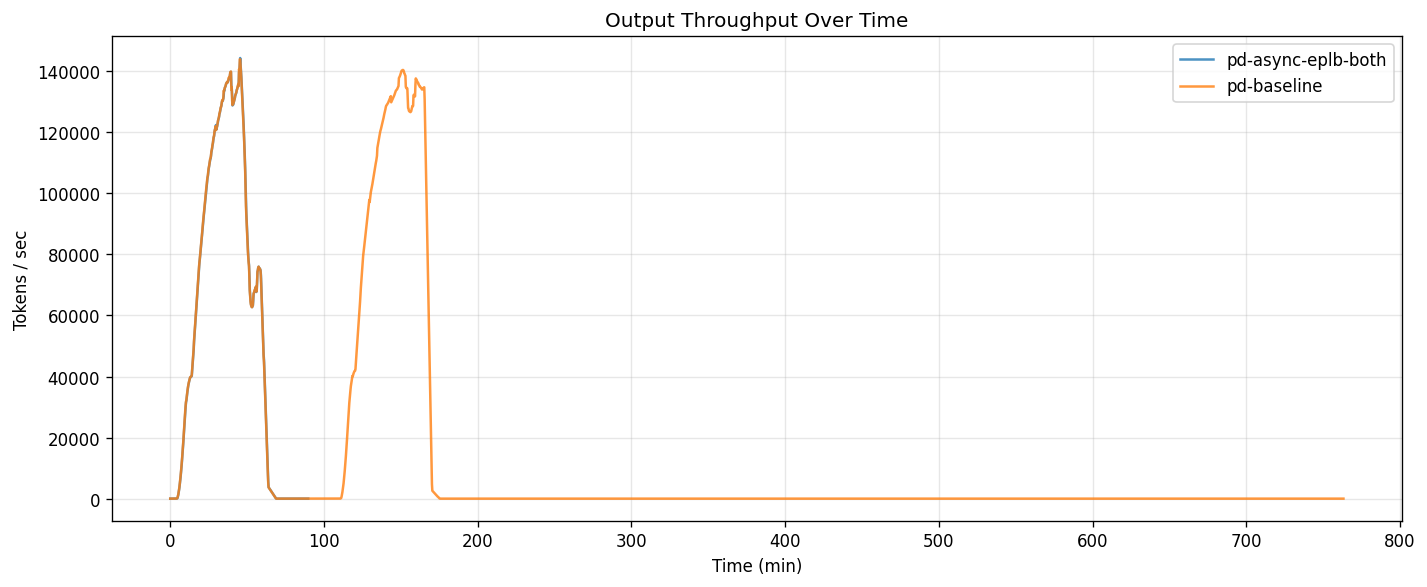

In [7]:
plot_throughput_comparison(runs)
plt.show()
plot_throughput_timeseries(runs)
plt.show()

## 4b. Throughput vs Interactivity (Pareto Frontier)

Each point is one concurrency stage. The curve shows the tradeoff: as system throughput
increases (more concurrent users), per-user output speed degrades.

Points on the upper-right frontier are optimal — you can't improve one axis without
sacrificing the other. Annotations show concurrency at each point.

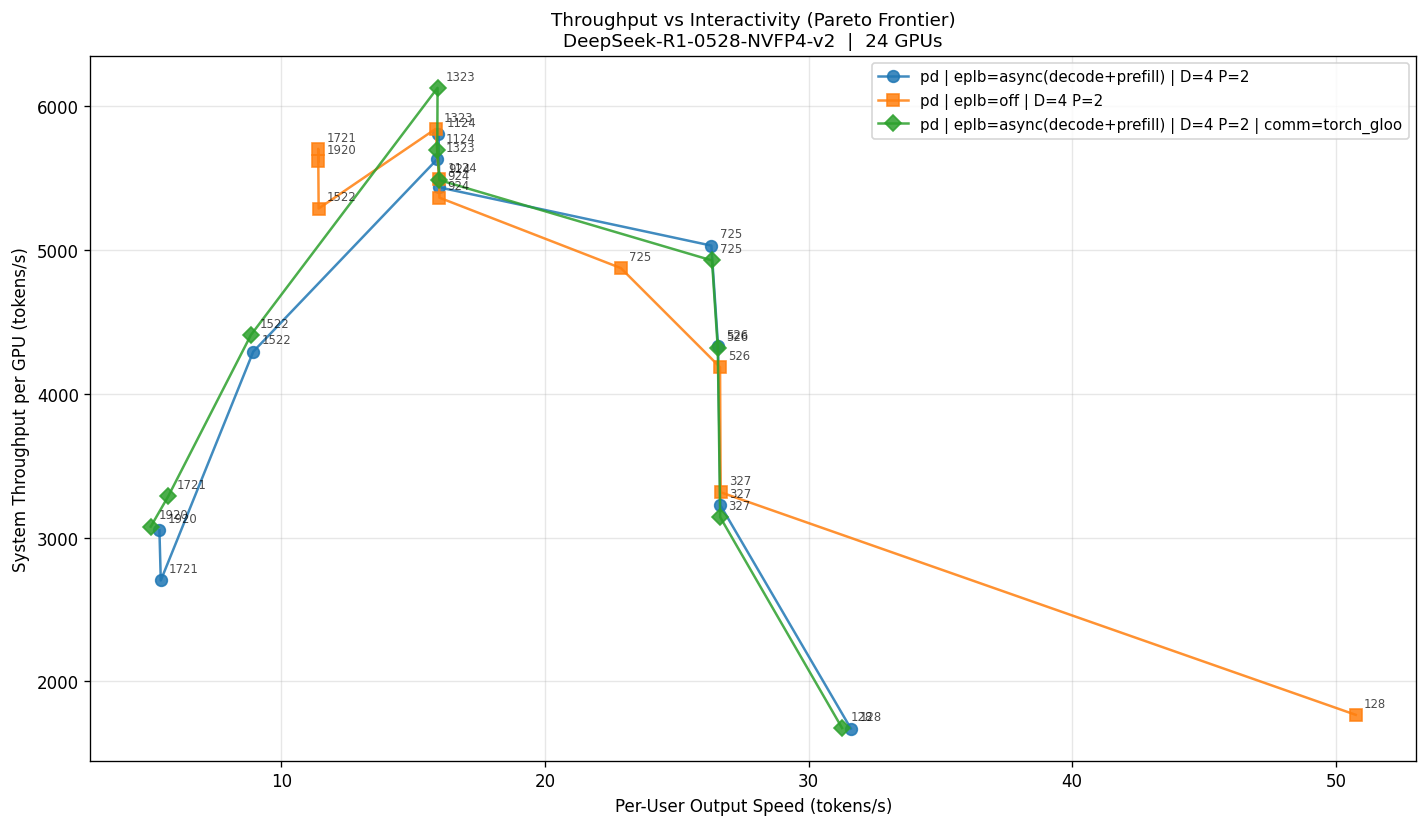


=== pd-async-eplb-both: per-stage metrics ===


,concurrency,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,itl_p50_ms,itl_p95_ms,itl_p99_ms,e2e_p50_ms,e2e_p95_ms,e2e_p99_ms,queue_p50_ms,queue_p95_ms,queue_p99_ms,prefill_time_p50_ms,prefill_time_p95_ms,prefill_time_p99_ms,decode_time_p50_ms,decode_time_p95_ms,decode_time_p99_ms,gen_tokens_per_sec,prompt_tokens_per_sec,requests_running,requests_waiting,kv_cache_usage,nixl_xfer_p99
stage,,,,,,,,,,,,,,,,,,,,,,,,,
0,128,245.424,2280.656,4726.551,31.641,48.207,49.679,1933.025,38891.937,46325.904,155.769,295.961,2481.274,169.791,1040.920,1492.654,288.558,38867.728,46255.457,40131.585,58406.565,2229.000,401.000,0.044,0.049
1,327,248.147,2973.829,8227.055,37.516,48.781,49.782,3211.285,57333.070,59478.213,156.629,297.595,3717.008,186.756,1091.926,1500.594,294.371,57150.141,59442.423,77372.906,76487.769,3157.000,912.000,0.074,0.049
2,526,260.140,2625.577,7781.110,37.642,49.020,53.060,3536.560,103592.252,116718.450,158.000,337.989,5476.770,200.660,1084.202,1470.193,289.942,99351.248,115870.250,103954.739,95527.973,5012.000,698.000,0.115,0.050
3,725,381.213,3534.041,7130.571,38.006,49.712,69.048,4595.284,110667.448,118133.490,159.480,664.034,3739.394,216.598,1178.584,1482.659,292.423,110635.038,118127.008,120678.124,103254.749,6721.000,607.000,0.159,0.071
4,924,437.433,3617.246,7134.373,62.523,73.808,74.811,5445.571,112075.896,118415.179,161.334,872.759,3919.494,220.890,1284.354,1586.121,294.432,112054.809,118410.962,130387.003,106561.559,8022.000,886.000,0.191,0.075
5,1124,446.965,1681.651,4384.804,62.652,74.038,79.483,3565.056,112740.079,118562.125,155.443,295.342,2928.620,213.903,965.951,1415.191,294.058,112718.408,118557.833,139212.913,113440.666,9512.000,568.000,0.222,0.075
6,1323,529.215,4816.300,8609.964,62.850,74.427,92.411,5878.906,186239.309,229247.862,160.082,718.866,3674.680,240.102,1166.288,1473.663,293.307,181127.720,228225.544,135074.960,105966.726,10995.000,442.000,0.269,0.095
7,1522,604.271,4111.602,6943.545,111.902,178.523,198.763,4640.112,218071.604,235614.321,163.179,1056.066,2405.806,194.501,1217.456,1477.183,285.493,217703.457,235540.691,103001.462,75949.251,12295.000,272.000,0.347,0.198
8,1721,823.516,9733.313,18183.189,184.206,282.633,297.589,3232.964,448029.568,473605.914,199.566,809.265,4132.822,180.844,920.000,1405.801,284.184,447671.100,473534.220,64843.338,43643.886,14868.000,395.000,0.397,0.488



=== pd-baseline: per-stage metrics ===


,concurrency,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,itl_p50_ms,itl_p95_ms,itl_p99_ms,e2e_p50_ms,e2e_p95_ms,e2e_p99_ms,queue_p50_ms,queue_p95_ms,queue_p99_ms,prefill_time_p50_ms,prefill_time_p95_ms,prefill_time_p99_ms,decode_time_p50_ms,decode_time_p95_ms,decode_time_p99_ms,gen_tokens_per_sec,prompt_tokens_per_sec,requests_running,requests_waiting,kv_cache_usage,nixl_xfer_p99
stage,,,,,,,,,,,,,,,,,,,,,,,,,
0,128,244.607,3751.434,6981.540,19.703,44.516,48.926,2131.549,38890.091,46422.996,159.913,778.213,4440.655,177.861,1209.058,1784.407,283.889,38862.123,46325.634,42431.224,62124.997,2671.000,4.000,0.043,0.047
1,327,245.564,2039.386,5303.562,37.504,48.757,49.757,2581.212,48720.275,52626.354,155.820,296.057,3453.857,181.700,1010.927,1556.373,293.281,48379.189,49730.865,79547.642,79034.211,3752.000,447.000,0.073,0.048
2,526,258.257,4195.554,9250.962,37.535,48.817,49.820,4372.172,107627.164,117525.433,160.353,1407.154,6521.934,191.586,1197.325,1590.528,289.474,107559.415,117511.883,100397.254,92167.696,5616.000,170.000,0.109,0.049
3,725,387.313,3439.130,7345.651,43.706,71.245,74.261,4615.052,110917.522,118183.504,159.280,728.590,4418.504,205.397,1164.185,1491.475,292.880,110881.640,118176.328,116926.793,100612.619,7171.000,237.000,0.143,0.072
4,924,437.528,3882.903,7344.893,62.513,73.787,74.789,5975.223,112060.143,118412.029,159.521,649.730,4297.963,216.600,1152.566,1475.051,293.822,112030.876,118406.175,128670.278,106591.716,8628.000,339.000,0.181,0.074
5,1124,452.621,2284.743,4553.289,62.552,73.849,74.853,4043.321,112812.723,118575.452,156.728,297.782,3167.178,208.741,995.960,1438.484,292.640,112792.053,118567.651,131783.361,107689.037,10326.000,189.000,0.215,0.074
6,1323,494.706,7534.818,16816.521,63.091,74.884,94.726,4961.347,115357.700,170630.976,156.596,297.533,1998.639,209.306,987.814,1424.135,294.594,113159.486,118650.606,140132.970,109105.639,11482.000,355.000,0.250,0.096
7,1522,600.238,6615.191,14512.670,87.597,99.112,128.908,5435.261,217770.768,235554.154,159.352,607.935,1884.231,212.827,1161.604,1466.331,292.413,216814.984,235362.997,126858.124,99910.632,12989.000,233.000,0.273,0.164
8,1721,603.582,43033.083,72606.617,87.724,99.356,135.053,5250.851,222730.722,236546.144,157.573,299.388,4275.577,202.917,1025.727,1437.699,292.896,221516.688,236303.338,136812.147,103455.697,12424.000,143.000,0.281,0.165



=== pd-async-eplb-both-gloo: per-stage metrics ===


,concurrency,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,itl_p50_ms,itl_p95_ms,itl_p99_ms,e2e_p50_ms,e2e_p95_ms,e2e_p99_ms,queue_p50_ms,queue_p95_ms,queue_p99_ms,prefill_time_p50_ms,prefill_time_p95_ms,prefill_time_p99_ms,decode_time_p50_ms,decode_time_p95_ms,decode_time_p99_ms,gen_tokens_per_sec,prompt_tokens_per_sec,requests_running,requests_waiting,kv_cache_usage,nixl_xfer_p99
stage,,,,,,,,,,,,,,,,,,,,,,,,,
0,128,244.551,1155.876,3515.278,31.979,48.242,49.687,1649.137,39083.235,46786.767,151.406,287.671,299.784,169.007,479.376,1217.641,296.180,39026.748,46648.698,40233.013,57150.753,1533.000,1105.000,0.036,0.050
1,327,249.560,3055.838,6675.261,37.529,48.806,49.808,3144.126,57880.713,59587.170,157.410,299.079,4422.561,191.852,1144.865,3074.184,291.171,57872.592,59585.588,75395.933,76368.057,2980.000,1221.000,0.073,0.049
2,526,260.047,2229.788,5795.358,37.657,49.050,55.403,3277.292,105738.145,117147.629,156.255,296.885,4282.848,210.457,996.364,1448.454,291.409,105437.448,117087.490,103609.181,93693.572,4597.000,1152.000,0.114,0.049
3,725,378.371,2050.407,5710.392,37.971,49.645,68.890,3826.861,110826.671,118165.334,155.618,295.674,3887.121,220.784,882.509,1441.165,293.513,110793.303,118158.661,118197.438,101019.037,6089.000,1233.000,0.150,0.063
4,924,447.480,3837.505,7436.027,62.503,73.841,74.849,5502.772,111979.318,118395.864,160.324,739.845,4317.899,232.121,1212.497,1481.729,292.984,111951.286,118390.257,131597.579,107878.652,7714.000,1155.000,0.195,0.074
5,1124,463.349,2565.578,5317.962,62.833,74.385,91.067,4657.578,112751.030,118562.785,156.734,297.795,3611.053,232.011,1046.854,1475.199,294.196,112735.254,118559.658,136612.873,110626.151,9176.000,283.000,0.228,0.074
6,1323,566.513,3974.256,8414.965,62.788,74.308,90.168,6434.205,113060.661,118621.838,159.878,773.059,2867.795,233.851,1164.826,1471.298,294.236,113030.126,118615.774,146984.575,116999.933,10594.000,170.000,0.264,0.091
7,1522,614.147,3297.821,4941.111,113.023,159.438,197.152,4158.289,221416.146,236283.229,165.191,894.662,2399.808,207.825,1227.969,1470.925,287.255,221322.322,236264.464,105778.268,74262.221,12655.000,1080.000,0.358,0.195
8,1721,791.323,2391.935,6085.961,175.029,197.905,199.938,4982.993,423512.784,468702.557,193.057,498.439,4194.249,235.330,974.604,1414.398,289.778,422996.956,468599.391,78894.662,54250.438,14048.000,1264.000,0.371,0.282


In [15]:
plot_pareto_frontier(runs)
plt.show()

# Per-stage metrics table for the first run with stages
for name, run in runs.items():
    df_stages = stage_metrics_table(run)
    if df_stages is not None:
        print(f"\n=== {name}: per-stage metrics ===")
        display(df_stages)

## 5. KV Cache Usage

Important for `num_redundant_experts` sweeps -- more redundant experts consume memory that would otherwise hold KV cache.

In [ ]:
plot_kv_cache_usage(runs)
plt.show()

## 6. Expert Load Balancedness

### 6a. Cross-run balancedness comparison

In [5]:
df_bal = balancedness_comparison_table(runs)
if not df_bal.empty:
    display(df_bal)
else:
    print("No expert load data available.")

,role,eplb,model,snapshots,final_mean_bal,final_worst_bal,avg_mean_bal,avg_worst_bal
run,,,,,,,,
pd-async-eplb-both (decode),decode,async,nvidia/DeepSeek-R1-0528-NVFP4-v2,83,0.259,0.250,0.666,0.579
pd-async-eplb-both (prefill),prefill,async,nvidia/DeepSeek-R1-0528-NVFP4-v2,27,0.984,0.960,0.940,0.876


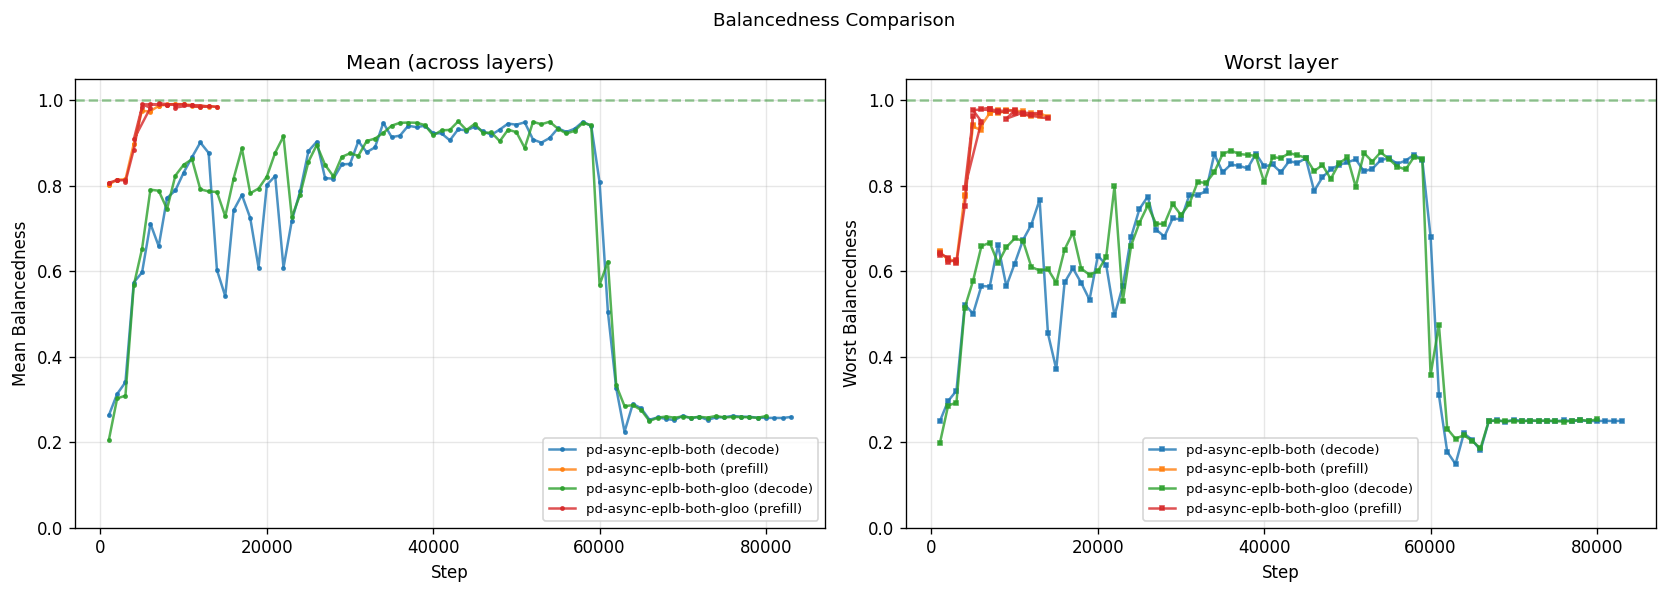

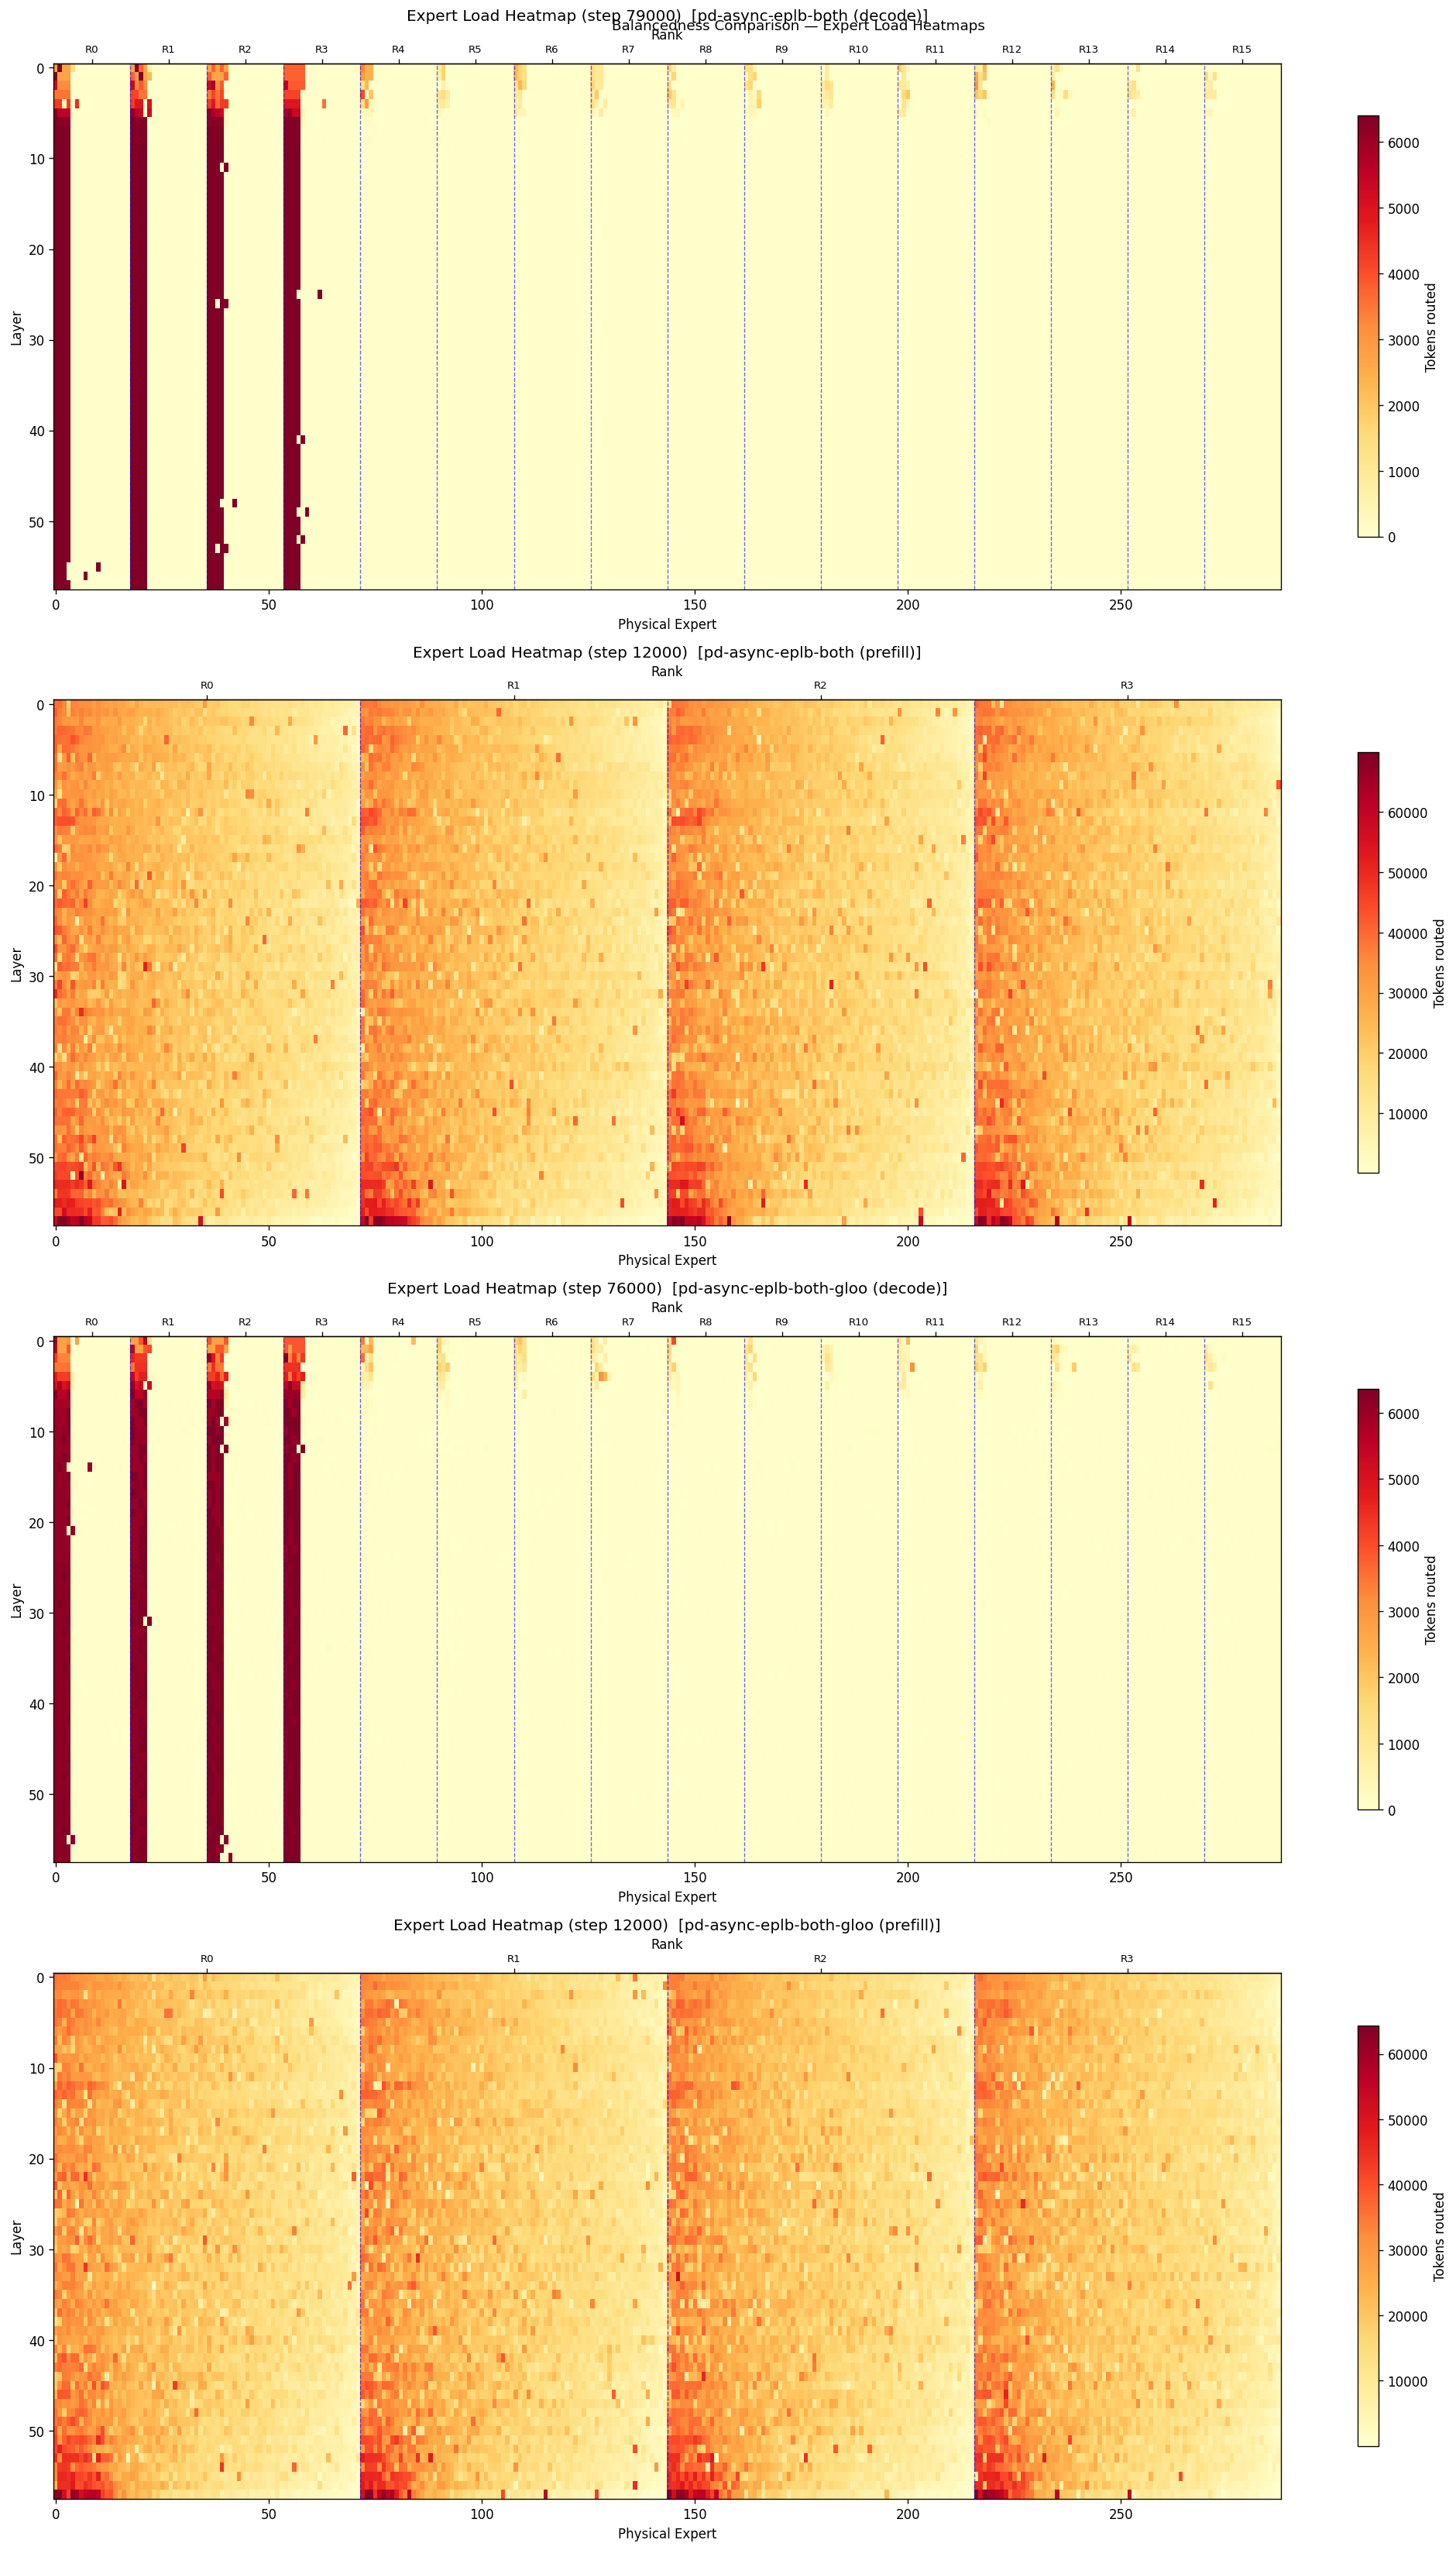

In [16]:

plot_balancedness_comparison(runs, snapshot_idx=-5)
plt.show()

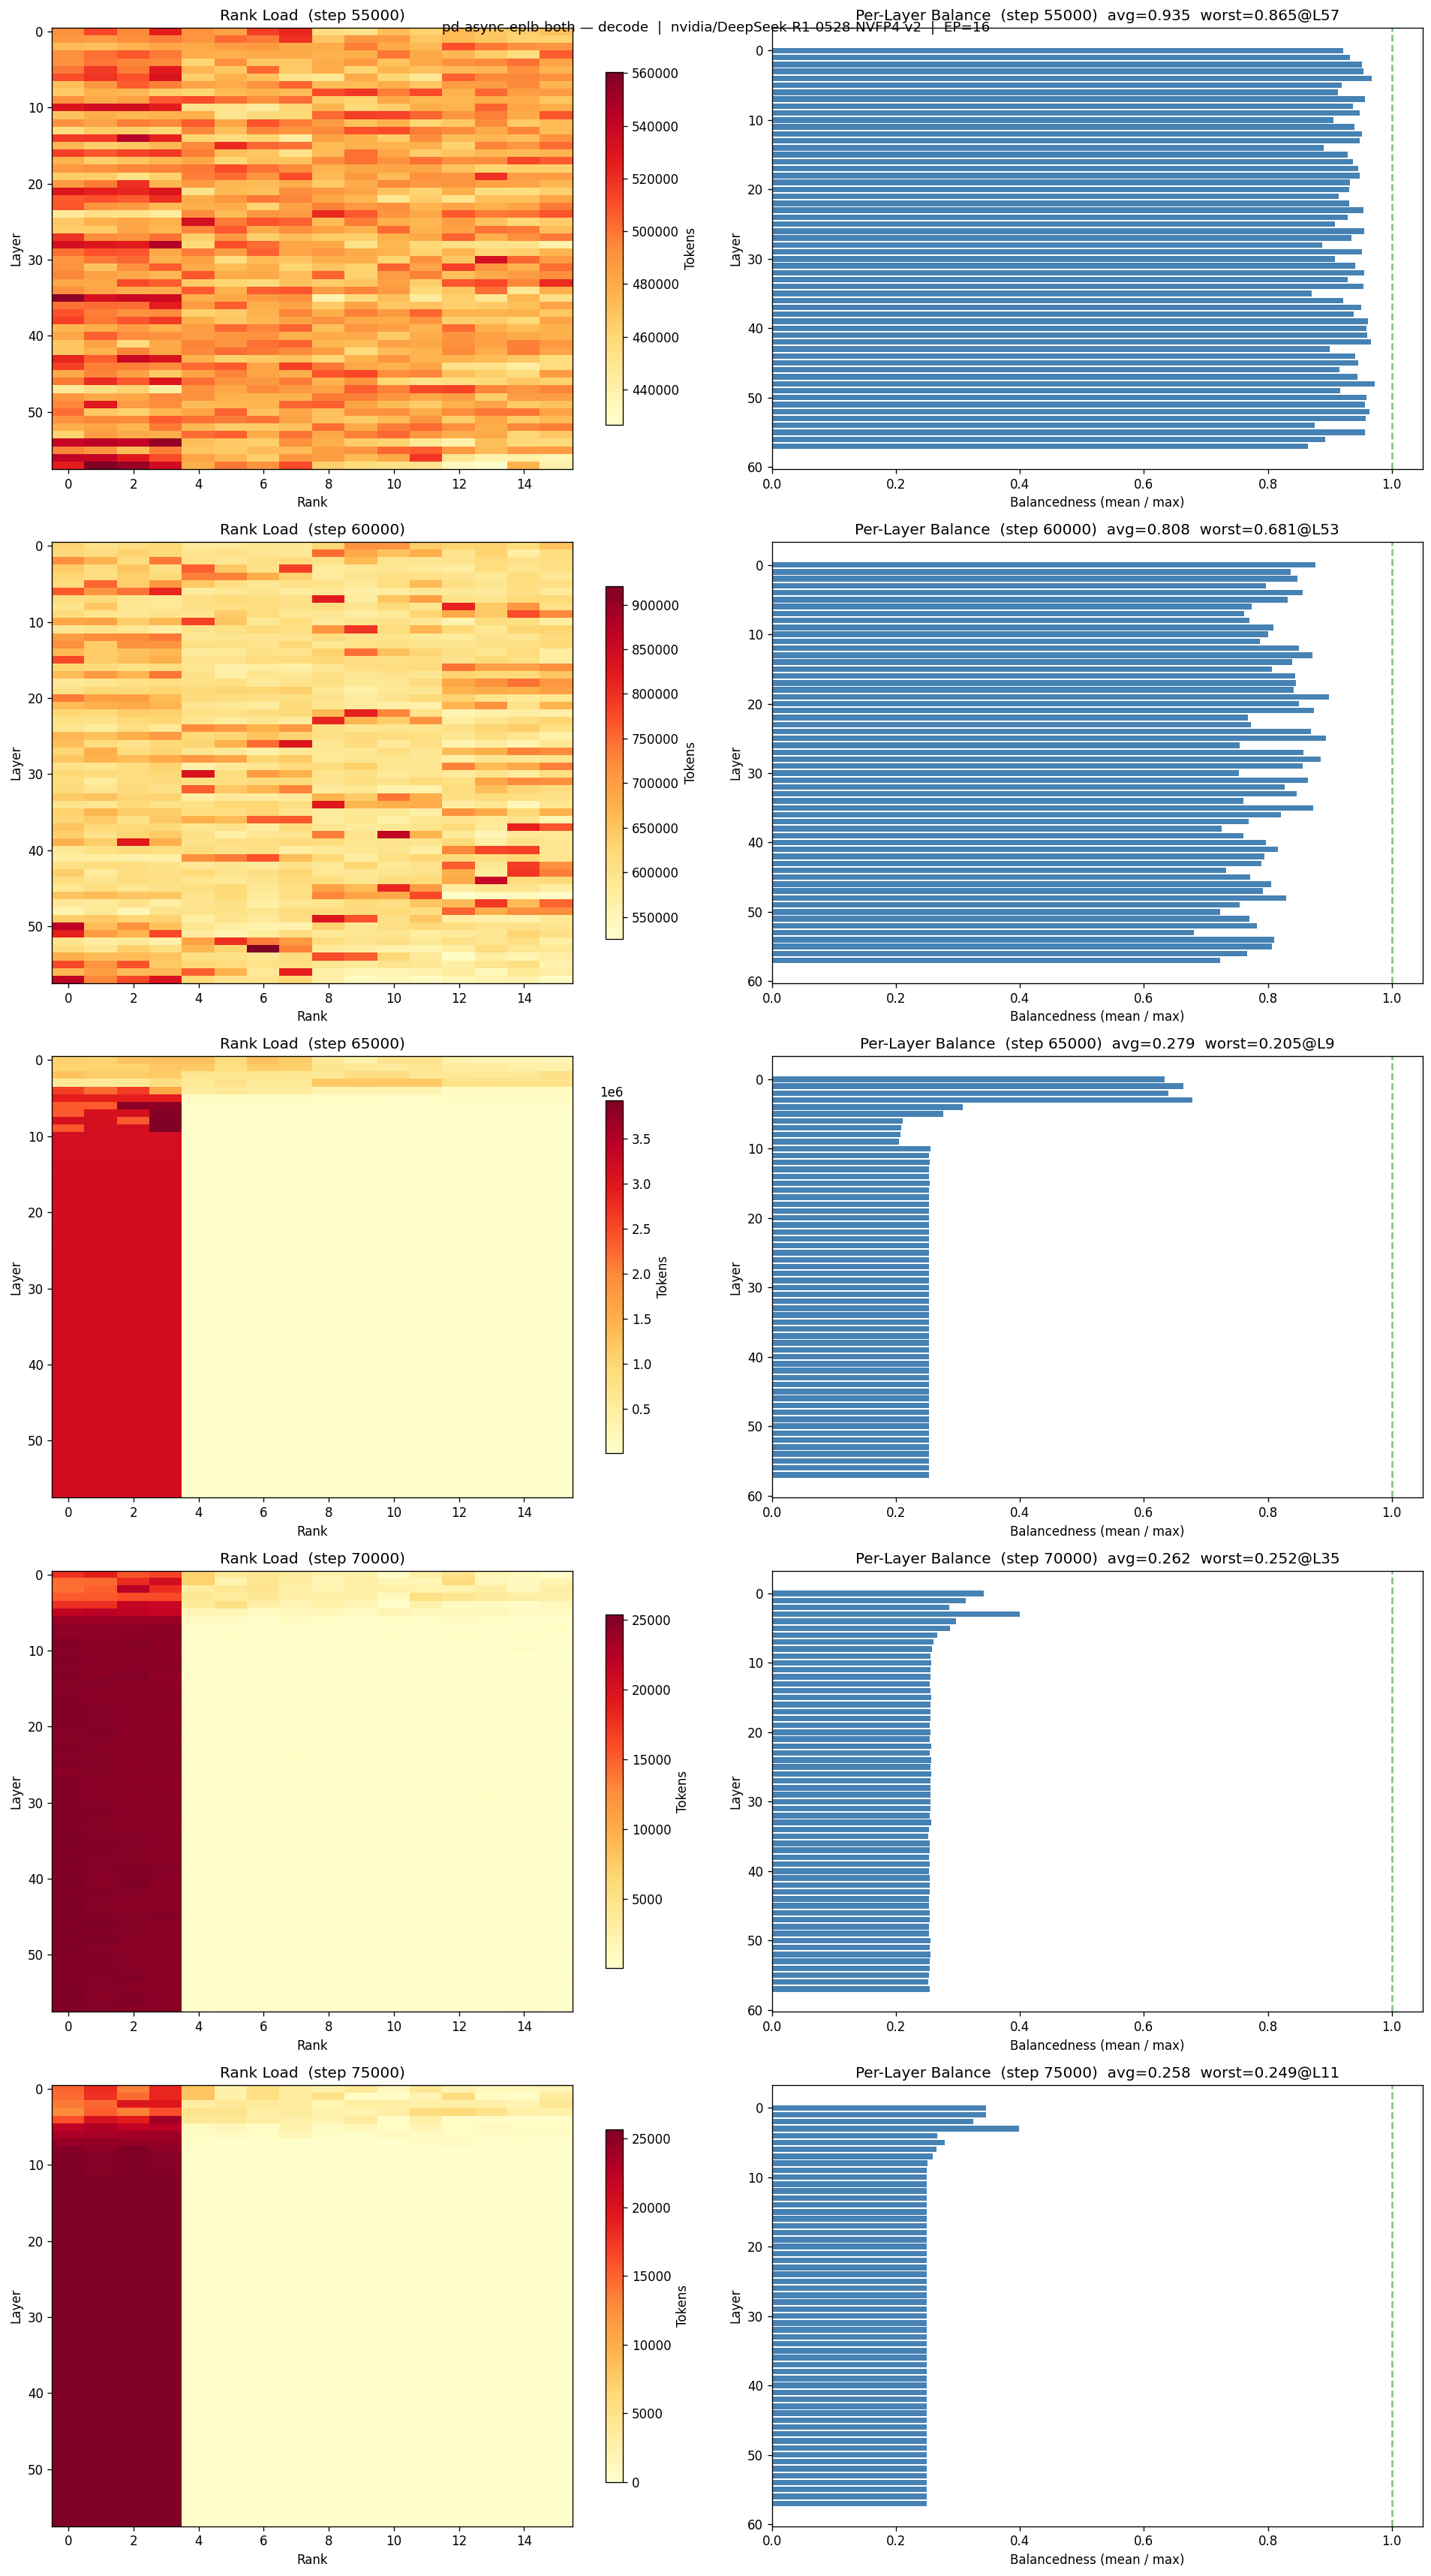

In [21]:
run = runs["pd-async-eplb-both"]
plot_rank_balance_at_steps(run, steps=[55000, 60000, 65000, 70000, 75000])

### 6b. Per-run deep dive

Select a single run to see its full expert load analysis (heatmap, rank balance, popularity, balancedness trend).

In [ ]:
# Pick a run to deep-dive (change the name here)
dive_run_name = run_names[0] if run_names else None

if dive_run_name and runs[dive_run_name].expert_loads:
    dive_run = runs[dive_run_name]
    for model_key, expert_data in dive_run.expert_loads.items():
        print(f"\n=== {dive_run_name} / {model_key} ===")
        print(f"  Model: {expert_data.model}")
        print(f"  EP width: {expert_data.world_size}")
        print(f"  Layers: {expert_data.num_layers}, Physical experts: {expert_data.num_physical}")
        print(f"  Redundant: {expert_data.num_redundant}, Per rank: {expert_data.experts_per_rank}")
        print(f"  Snapshots: {expert_data.num_snapshots}")
        plot_expert_load_all(expert_data, title_suffix=f"  [{dive_run_name}]")
        plt.show()
else:
    print(f"No expert load data for {dive_run_name}")

## 7. Phase 2: Parameter Sweep Analysis

Use these cells when comparing `num_redundant_experts` or `step_interval` sweeps. Adjust the `filter_*` calls to select the relevant runs.

In [ ]:
def filter_runs_by_prefix(runs: dict, prefix: str) -> dict:
    """Filter runs whose name starts with a prefix (e.g. 'nre-' for redundant expert sweep)."""
    return {k: v for k, v in runs.items() if k.startswith(prefix)}

# Example: num_redundant_experts sweep
nre_runs = filter_runs_by_prefix(runs, "nre-")
if nre_runs:
    print(f"num_redundant_experts sweep: {list(nre_runs.keys())}")
    plot_latency_comparison(nre_runs, title="Latency vs num_redundant_experts")
    plt.show()
    plot_throughput_comparison(nre_runs, title="Throughput vs num_redundant_experts")
    plt.show()
    plot_kv_cache_usage(nre_runs, title="KV Cache vs num_redundant_experts")
    plt.show()
    plot_balancedness_comparison(nre_runs, title="Balancedness vs num_redundant_experts")
    plt.show()
else:
    print("No nre-* runs found. Run Phase 2A sweep first.")

In [ ]:
# Example: step_interval sweep
si_runs = filter_runs_by_prefix(runs, "si-")
if si_runs:
    print(f"step_interval sweep: {list(si_runs.keys())}")
    plot_latency_comparison(si_runs, title="Latency vs step_interval")
    plt.show()
    plot_throughput_comparison(si_runs, title="Throughput vs step_interval")
    plt.show()
    plot_balancedness_comparison(si_runs, title="Balancedness vs step_interval")
    plt.show()
else:
    print("No si-* runs found. Run Phase 2B sweep first.")

In [ ]:
# Example: LWS scale sweep
lws_runs = filter_runs_by_prefix(runs, "lws-")
if lws_runs:
    print(f"LWS scale sweep: {list(lws_runs.keys())}")
    plot_latency_comparison(lws_runs, title="Latency vs LWS Size")
    plt.show()
    plot_throughput_comparison(lws_runs, title="Throughput vs LWS Size")
    plt.show()
    plot_balancedness_comparison(lws_runs, title="Balancedness vs LWS Size")
    plt.show()
else:
    print("No lws-* runs found. Run Phase 2C sweep first.")

## 8. Custom Queries

Scratch cells for ad-hoc analysis.

In [ ]:
# Example: compare two specific runs side by side
# run_a = load_run("pd-sync-eplb")
# run_b = load_run("pd-async-eplb")
# subset = {"sync": run_a, "async": run_b}
# plot_latency_comparison(subset)
# plot_throughput_comparison(subset)

In [ ]:
# Example: access raw Prometheus range data for custom plotting
# run = runs[run_names[0]]
# if run.prometheus:
#     df = run.prometheus.range_series("gen_tokens_per_sec_range")
#     if df is not None:
#         df.plot(x="time_min", y="value", title=f"{run.name} throughput")
#         plt.show()